INSIGHT 1: Demografi dan Hubungannya dengan Kepatuhan
Analisis: Dataset mencakup usia (Age), pendidikan (Educational Attainment), dan status pernikahan (Marital Status). Terdapat variasi latar belakang seperti pendidikan dari FLSC hingga Postgraduate, dan usia dari di bawah 21 hingga di atas 50 tahun.
Pertanyaan Bisnis SMART:
"Berapa persentase tingkat 'High Non-Adherent' pada kelompok usia 'Di atas 50 tahun' dengan tingkat pendidikan menengah ke bawah (WASC/SSCE) dibandingkan kelompok lainnya selama periode survei ini, untuk menentukan target demografis utama pada program edukasi kesehatan kuartal berikutnya?"

INSIGHT 2: Potensi Intervensi Melalui Komunikasi
Analisis: Terdapat fitur kepemilikan ponsel (Do you have a mobile phone), frekuensi menerima SMS (How often do you receive text messages/alerts in a day), frekuensi menjawab telepon, dan bahasa komunikasi utama (English, Igbo, Hausa). Ini membuka peluang intervensi digital.
Pertanyaan Bisnis SMART:
"Apakah pasien yang memiliki ponsel dan merespons pesan teks/panggilan dengan frekuensi 'Very Often' memiliki tingkat kepatuhan ('High Adherent') minimal 15% lebih tinggi dibandingkan yang tidak memiliki ponsel selama periode observasi ini, sehingga sistem pengingat SMS Gateway multi-bahasa layak diimplementasikan bulan depan?"

INSIGHT 3: Rutinitas Harian dan Peran Pengasuh (Caregiver)
Analisis: Fitur seperti jam kerja sehari (How many hours do work in a day) hingga 24 jam, dan siapa pengasuhnya (Self, Spouse, Children) sangat memengaruhi apakah seseorang sering lupa minum obat atau tidak.
Pertanyaan Bisnis SMART:
"Bagaimana perbandingan rasio 'High Adherent' antara pasien yang bekerja lebih dari 12 jam sehari dan mengurus dirinya sendiri ('Self') dengan mereka yang dibantu oleh keluarga ('Spouse/Children') pada data ini, untuk merancang panduan pelibatan keluarga (Family Support System) dalam 6 bulan ke depan?"

INSIGHT 4: Beban Resep dan Alasan Konsumsi Obat
Analisis: Fitur jumlah obat (Number of drugs prescribed), jumlah tablet per hari, waktu minum obat, dan alasan memilih waktu tersebut (misal: 'easier to remember', 'doctor told me') menunjukkan kompleksitas beban medis pasien.
Pertanyaan Bisnis SMART:
"Berapa tingkat peningkatan persentase 'High Non-Adherent' pada pasien yang harus meminum lebih dari 3 tablet sehari ('Above three') dibandingkan pasien dengan 1-2 tablet per hari pada periode saat ini, sebagai dasar bagi dokter untuk mengevaluasi penyederhanaan resep di klinik mulai bulan depan?"

INSIGHT 5: Kondisi Kesehatan Spesifik
Analisis: Kolom 'Health Condition' menunjukkan variasi penyakit kronis utama seperti HIV, Hipertensi, Diabetes, Glaukoma, dan Mental. Tingkat kepatuhan bisa sangat bergantung pada jenis penyakit yang diderita pasien.
Pertanyaan Bisnis SMART:
"Di antara pasien dengan kondisi kesehatan kronis utama (HIV, Hipertensi, dan Diabetes), kelompok manakah yang mencatatkan rasio 'Low/High Non-Adherent' tertinggi selama pencatatan data ini, agar tim medis dapat mengalokasikan 50% tambahan jam konseling khusus bagi kelompok tersebut pada kuartal mendatang?"

INSIGHT 6: Pengaruh Level Pengetahuan, Persepsi, dan Perilaku
Analisis: Fitur kategori seperti 'PERCEPTION LEVEL' (Bad, Fair, Good), 'BEHAVIOUR LEVEL' (Highly forgetful, Not forgetful), dan 'KNOWLEDGE LEVEL' (Inadequate, Moderate, Good) mengukur aspek psikologis pasien terhadap tingkat kepatuhannya (ADHERENCE LEVEL).
Pertanyaan Bisnis SMART:
"Seberapa besar korelasi (dalam persentase) antara pasien dengan 'KNOWLEDGE LEVEL: Inadequate' dan 'PERCEPTION LEVEL: Bad' terhadap probabilitas mereka masuk ke kategori 'HIGH NON-ADHERENT' pada survei ini, guna memutuskan apakah budget promosi kesehatan tahun ini harus difokuskan pada kampanye perbaikan pengetahuan atau intervensi perilaku?"


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/DATA CAPS/MULTI DIMENSIONAL ADHERENCE DATASET IN SOUTHEAST NIGERIA.xlsx'
df = pd.read_excel(file_path)
df.head()

,S/N,GENDER,AGE,Marital Status,Religion Affiliation,Educational Attainment,Occupation,How many hours do work in a day,Who is your care giver,Do you have a mobile phone,...,42,43,44,45,46,47,48,49,50,51
0,1,female,31-40,married,Christianity,university first degreee,Professional,8 hours,Spouse,Yes,...,5.0,5.0,1.0,4.0,5.0,4.0,1.0,4.0,5.0,0
1,2,male,31-40,married,Christianity,WASC/SSCE,Trader,24 hours,Parent,Yes,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1
2,3,female,Above 50,widow/widower,Christianity,FLSC,Farmer,8 hours,Children,Yes,...,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1
3,4,female,31-40,married,Christianity,university first degreee,Trader,12 hours,Spouse,Yes,...,5.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,5.0,1
4,5,female,41-50,married,Christianity,WASC/SSCE,Farmer,8 hours,Spouse,NaN,...,5.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,0


In [7]:
# 1. Mengecek informasi umum dataframe (tipe data dan jumlah non-null)
print("=== INFO DATASET ===")
df.info()

# 2. Mengecek Missing Value ekstrem (Kolom yang 100% kosong)
empty_cols = [col for col in df.columns if df[col].isnull().all()]
print(f"\n=== KOLOM KOSONG (100% NaN) ===\n{empty_cols}")

# 3. Mengecek Duplikasi Data
print(f"\n=== JUMLAH DATA DUPLIKAT: {df.duplicated().sum()} ===")

# 4. Mengecek nama kolom yang berupa angka (Nomor pertanyaan kuesioner)
numbered_cols = [col for col in df.columns if str(col).isdigit()]
print(f"\n=== KOLOM BERUPA ANGKA (PERTANYAAN) ===\n{numbered_cols}")


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 64 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   S/N                                                     609 non-null    int64  
 1   GENDER                                                  609 non-null    object 
 2   AGE                                                     605 non-null    object 
 3   Marital Status                                          605 non-null    object 
 4   Religion Affiliation                                    604 non-null    object 
 5   Educational Attainment                                  551 non-null    object 
 6   Occupation                                              608 non-null    object 
 7   How many hours do work in a day                         595 non-null    object 
 8   Who is your care gi

In [9]:
# 1. Mengatasi Missing Value: Menghapus (drop) kolom yang 100% kosong dengan aman
initial_cols = df.shape[1]
df.dropna(axis=1, how='all', inplace=True)
final_cols = df.shape[1]
print(f"Jumlah kolom kosong yang berhasil dihapus: {initial_cols - final_cols}")

# 2. Mengatasi Nama Kolom Berupa Angka (Kuesioner): Membuat kamus pemetaan (mapping)
# Kamus ini telah disesuaikan secara otomatis dari isi file Word Kuesioner Asli Anda.
question_mapping = {
    19: "How often would you change your mind to do what you have decided not to do?",
    20: "How often would you likely change your mind to do a thing if convinced or motivated?",
    21: "How often would you change or accept suggestions from care provider towards a change of your decision",
    22: "How often do you forget to do what you planned doing at the immediate",
    23: "How often do you forget something you were told a few minutes before",
    24: "How often do you miss appointments, if you are not prompted by someone or by a reminder such as phone call or SMS",
    25: "Why would you likely miss your drug(s), what usually the cause?",
    26: "What reminds you of your medication time and dose?",
    27: "Do you belief drug(s) can help your situation",
    28: "Taking drug is burdensome",
    29: "Drug alone is inadequate",
    30: "Are you aware of the sickness before you are diagnosed",
    31: "Are you aware that the sickness required certain lifestyle changes",
    32: "Are you aware the disease required prolonged treatment",
    33: "Do you sometimes forget to take your drug as prescribed?",
    34: "People sometimes fail to take their drug for reasons other than forgetting. Thinking over the past 2 weeks, were there any days when you did not take your drug?",
    35: "Have you ever cut back or stopped taking your drugs without telling your doctor because you felt worse when you use it?",
    36: "When you travel or leave home, do you sometimes forget to take along your drugs?",
    37: "Did you take all your prescribed drugs yesterday?",
    38: "When you feel like your symptoms are under control, do you sometimes stop taking your drugs?",
    39: "Taking drug every day is a real inconvenience for some people. Do you ever feel hassled about sticking to your medication plan?",
    40: "How often do you have difficulty in remembering to take your prescribed drugs?",
    # Kuesioner Bagian E (dimulai dari 36 di Word, bergeser menjadi 41-51 di dataset Excel)
    41: "People (including me) sometimes forget to take drugs as prescribed",
    42: "It is possible to forget time of taking drugs, number of drugs to be taken and number of times drugs should be taken",
    43: "Taking drug without doctor's advice will make health condition worse",
    44: "Alert messages, agent voice call, interactive voice response (IVR) calls and USSD will help to take their drugs as advised",
    45: "Persuasive, motivational, educational messages through voice call, SMS, USSD can help people to take their drugs as instructed",
    46: "Using IVR call, USSD and SMS messages explain the benefits of taking drugs as instructed will help people to take their drugs properly",
    47: "Using IVR call, USSD, and SMS messages to explain risk/danger of not taking drug will help people to take their drugs properly",
    48: "Do you think there are cost benefits in adapting mobile app services to deliver intervention functions",
    49: "Do you think healthcare provider, caregivers and patient should adapt the use of IVR calls, agent voice calls and SMS services to make drug intake better?",
    50: "The mobile app service could enable patients discuss with care providers before next appointment.",
    51: "Would you accept and use mobile app services as a person?"
}

numbered_cols = [col for col in df.columns if str(col).isdigit()]
rename_dict = {}

for col in numbered_cols:
    # Jika nomor pertanyaan ada di dalam mapping, gunakan deskripsinya. Jika tidak, pakai prefix Q_
    if col in question_mapping:
        rename_dict[col] = f"Q{col}: {question_mapping[col]}"
    else:
        rename_dict[col] = f"Q_{col}"

df.rename(columns=rename_dict, inplace=True)
print(f"Kolom pertanyaan disesuaikan dengan deskripsi kuesioner.")

Jumlah kolom kosong yang berhasil dihapus: 0
Kolom pertanyaan disesuaikan dengan deskripsi kuesioner.


In [10]:
# 3. Mengatasi Inconsistent Value: Standarisasi teks bahasa komunikasi
lang_col = 'What is your preferred communication language'
df[lang_col] = df[lang_col].astype(str).str.lower().str.strip()
print("\nNilai unik bahasa setelah standarisasi:")
print(df[lang_col].unique())

# 4. Mengatasi Duplicate Data: Menghapus baris yang identik (jika ada)
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]
print(f"\nJumlah baris duplikat yang dihapus: {initial_rows - final_rows}")

# Pengecekan Akhir
print("\nUkuran dataset setelah proses Cleaning:", df.shape)
df.head()


Nilai unik bahasa setelah standarisasi:
['english' 'igbo' 'hausa' 'nan' 'yoruba' 'housa']

Jumlah baris duplikat yang dihapus: 0

Ukuran dataset setelah proses Cleaning: (609, 64)


,S/N,GENDER,AGE,Marital Status,Religion Affiliation,Educational Attainment,Occupation,How many hours do work in a day,Who is your care giver,Do you have a mobile phone,...,"Q42: It is possible to forget time of taking drugs, number of drugs to be taken and number of times drugs should be taken",Q43: Taking drug without doctor's advice will make health condition worse,"Q44: Alert messages, agent voice call, interactive voice response (IVR) calls and USSD will help to take their drugs as advised","Q45: Persuasive, motivational, educational messages through voice call, SMS, USSD can help people to take their drugs as instructed","Q46: Using IVR call, USSD and SMS messages explain the benefits of taking drugs as instructed will help people to take their drugs properly","Q47: Using IVR call, USSD, and SMS messages to explain risk/danger of not taking drug will help people to take their drugs properly",Q48: Do you think there are cost benefits in adapting mobile app services to deliver intervention functions,"Q49: Do you think healthcare provider, caregivers and patient should adapt the use of IVR calls, agent voice calls and SMS services to make drug intake better?",Q50: The mobile app service could enable patients discuss with care providers before next appointment.,Q51: Would you accept and use mobile app services as a person?
0,1,female,31-40,married,Christianity,university first degreee,Professional,8 hours,Spouse,Yes,...,5.0,5.0,1.0,4.0,5.0,4.0,1.0,4.0,5.0,0
1,2,male,31-40,married,Christianity,WASC/SSCE,Trader,24 hours,Parent,Yes,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1
2,3,female,Above 50,widow/widower,Christianity,FLSC,Farmer,8 hours,Children,Yes,...,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1
3,4,female,31-40,married,Christianity,university first degreee,Trader,12 hours,Spouse,Yes,...,5.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,5.0,1
4,5,female,41-50,married,Christianity,WASC/SSCE,Farmer,8 hours,Spouse,NaN,...,5.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,0


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Setel gaya dasar visualisasi
sns.set_theme(style="whitegrid", palette="muted")

# Opsional: Persiapan/Pembersihan Lanjutan Khusus Analisis
col_target = 'NON ADHERENT LEVEL'
# Menyeragamkan label target menjadi uppercase dan menghapus spasi
df[col_target] = df[col_target].astype(str).str.upper().str.strip()

/tmp/ipykernel_3404/2611459090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col_target, order=df[col_target].value_counts().index, ax=ax[0], palette='viridis')


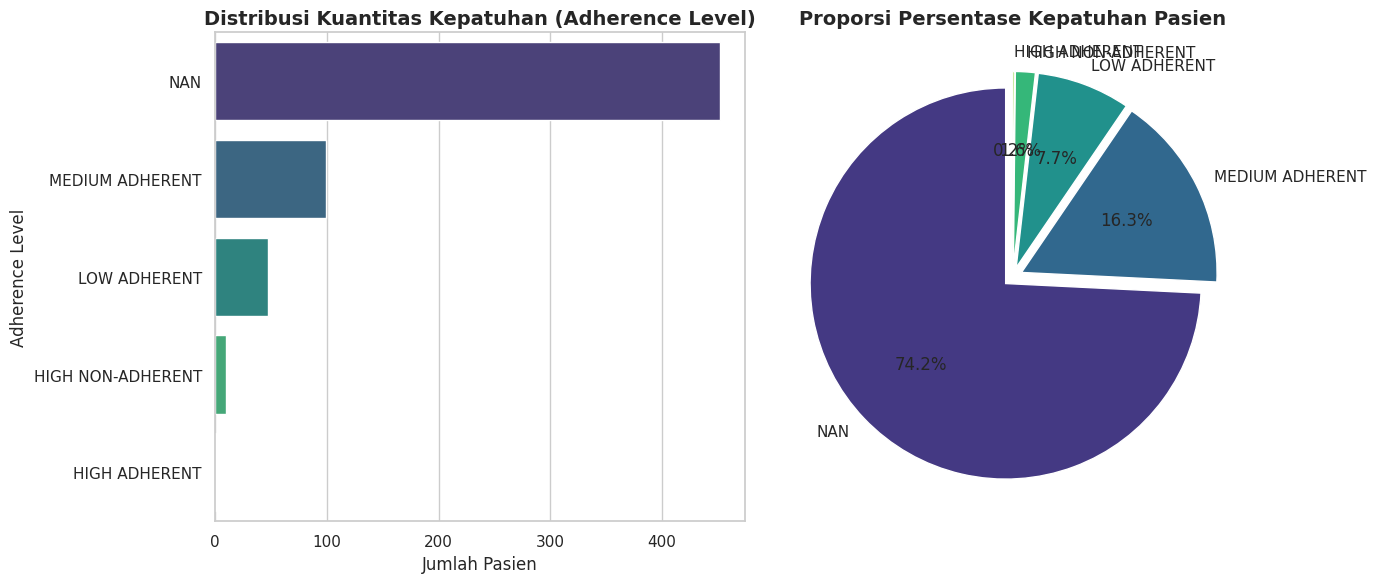

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Countplot untuk distribusi populasi target
sns.countplot(data=df, y=col_target, order=df[col_target].value_counts().index, ax=ax[0], palette='viridis')
ax[0].set_title('Distribusi Kuantitas Kepatuhan (Adherence Level)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Jumlah Pasien')
ax[0].set_ylabel('Adherence Level')

# 2. Pie Chart untuk persentase proporsi target
target_counts = df[col_target].value_counts()
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette('viridis', len(target_counts)), explode=[0.05]*len(target_counts))
ax[1].set_title('Proporsi Persentase Kepatuhan Pasien', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


/tmp/ipykernel_3404/1265135192.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Demo_Group', ax=ax[0], palette='Set2')


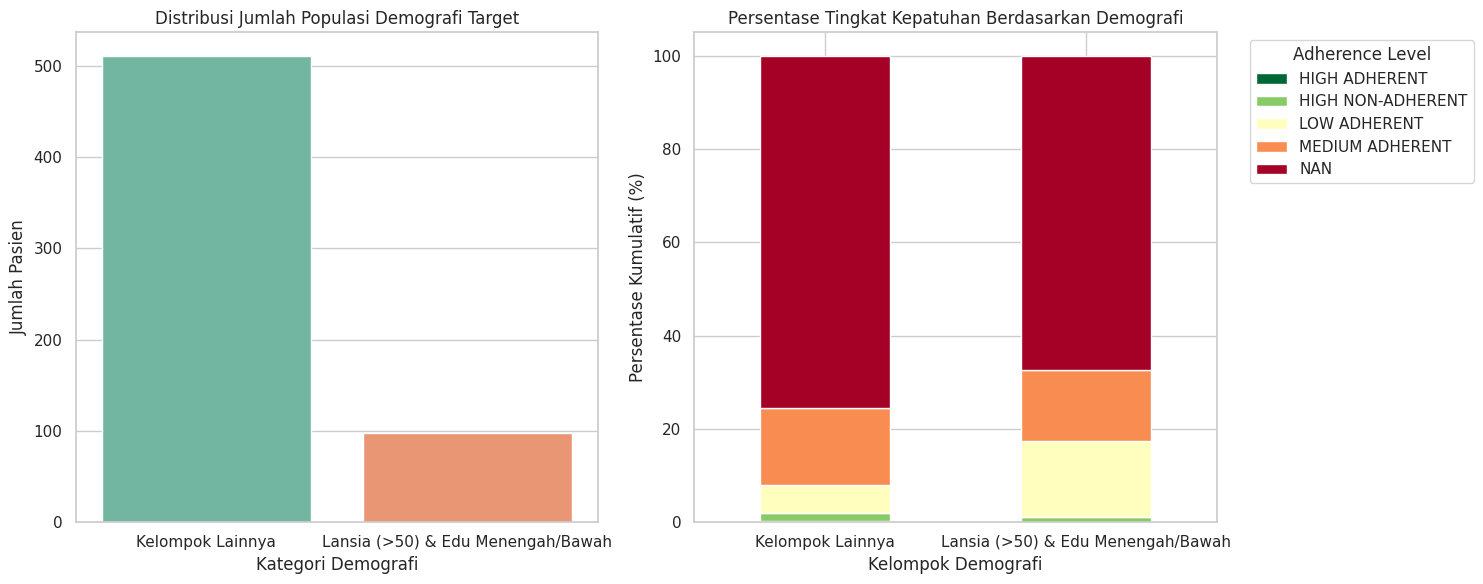

In [13]:
### Pertanyaan 1: Demografi dan Hubungannya dengan Kepatuhan
#"Berapa persentase tingkat 'High Non-Adherent' pada kelompok usia 'Di atas 50 tahun' dengan tingkat pendidikan menengah ke bawah (WASC/SSCE) dibandingkan kelompok lainnya?"*

def flag_demografi(row):
    age = str(row['AGE']).strip().upper()
    edu = str(row['Educational Attainment']).strip().upper()
    is_old = '50' in age and ('ABOVE' in age or '>' in age)
    # Asumsi WASC/SSCE, FLSC, FSLC sebagai pendidikan menengah ke bawah
    is_mid_low_edu = edu in ['WASC/SSCE', 'FLSC', 'FSLC']

    if is_old and is_mid_low_edu:
        return 'Lansia (>50) & Edu Menengah/Bawah'
    else:
        return 'Kelompok Lainnya'

df['Demo_Group'] = df.apply(flag_demografi, axis=1)
demo_adherence = pd.crosstab(df['Demo_Group'], df[col_target], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Visualisasi 1: Jumlah populasi di masing-masing grup demografi
sns.countplot(data=df, x='Demo_Group', ax=ax[0], palette='Set2')
ax[0].set_title('Distribusi Jumlah Populasi Demografi Target', fontsize=12)
ax[0].set_ylabel('Jumlah Pasien')
ax[0].set_xlabel('Kategori Demografi')

# Visualisasi 2: Persentase Kepatuhan (Stacked Barplot)
demo_adherence.plot(kind='bar', stacked=True, ax=ax[1], colormap='RdYlGn_r')
ax[1].set_title('Persentase Tingkat Kepatuhan Berdasarkan Demografi', fontsize=12)
ax[1].set_ylabel('Persentase Kumulatif (%)')
ax[1].set_xlabel('Kelompok Demografi')
ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(title='Adherence Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

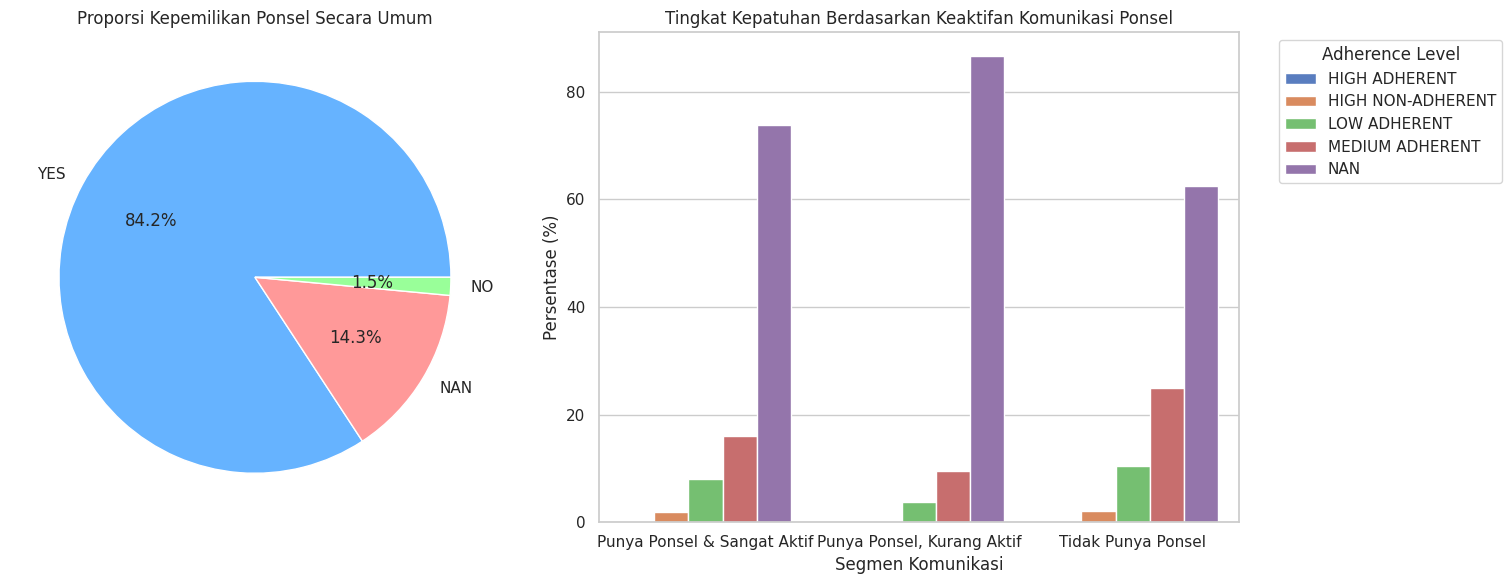

In [14]:
### Pertanyaan 2: Potensi Intervensi Melalui Komunikasi
#"Apakah pasien yang memiliki ponsel dan merespons pesan teks/panggilan 'Very Often' memiliki tingkat kepatuhan minimal 15% lebih tinggi dibandingkan yang tidak memiliki ponsel?"*
def flag_communication(row):
    has_phone = str(row['Do you have a mobile phone']).strip().upper() == 'YES'
    call_freq = str(row['How often do you answer phone calls in a day']).strip().upper()
    sms_freq = str(row['How often do you receive text messages/alerts in a day']).strip().upper()

    if not has_phone:
        return 'Tidak Punya Ponsel'
    elif 'OFTEN' in call_freq or 'OFTEN' in sms_freq:
        return 'Punya Ponsel & Sangat Aktif'
    else:
        return 'Punya Ponsel, Kurang Aktif'

df['Comm_Segment'] = df.apply(flag_communication, axis=1)
comm_adherence = pd.crosstab(df['Comm_Segment'], df[col_target], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi 1: Pie chart untuk kepemilikan ponsel murni (Konteks awal)
has_phone_counts = df['Do you have a mobile phone'].astype(str).str.upper().value_counts()
ax[0].pie(has_phone_counts, labels=has_phone_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999', '#99ff99'])
ax[0].set_title('Proporsi Kepemilikan Ponsel Secara Umum', fontsize=12)

# Visualisasi 2: Barplot Clustered untuk Segmen Komunikasi vs Kepatuhan
sns.barplot(data=comm_adherence.reset_index().melt(id_vars='Comm_Segment'), x='Comm_Segment', y='value', hue=col_target, ax=ax[1])
ax[1].set_title('Tingkat Kepatuhan Berdasarkan Keaktifan Komunikasi Ponsel', fontsize=12)
ax[1].set_ylabel('Persentase (%)')
ax[1].set_xlabel('Segmen Komunikasi')
ax[1].legend(title='Adherence Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3404/1150993116.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Caregiver Clean', order=df['Caregiver Clean'].value_counts().index, ax=ax[0], palette='pastel')


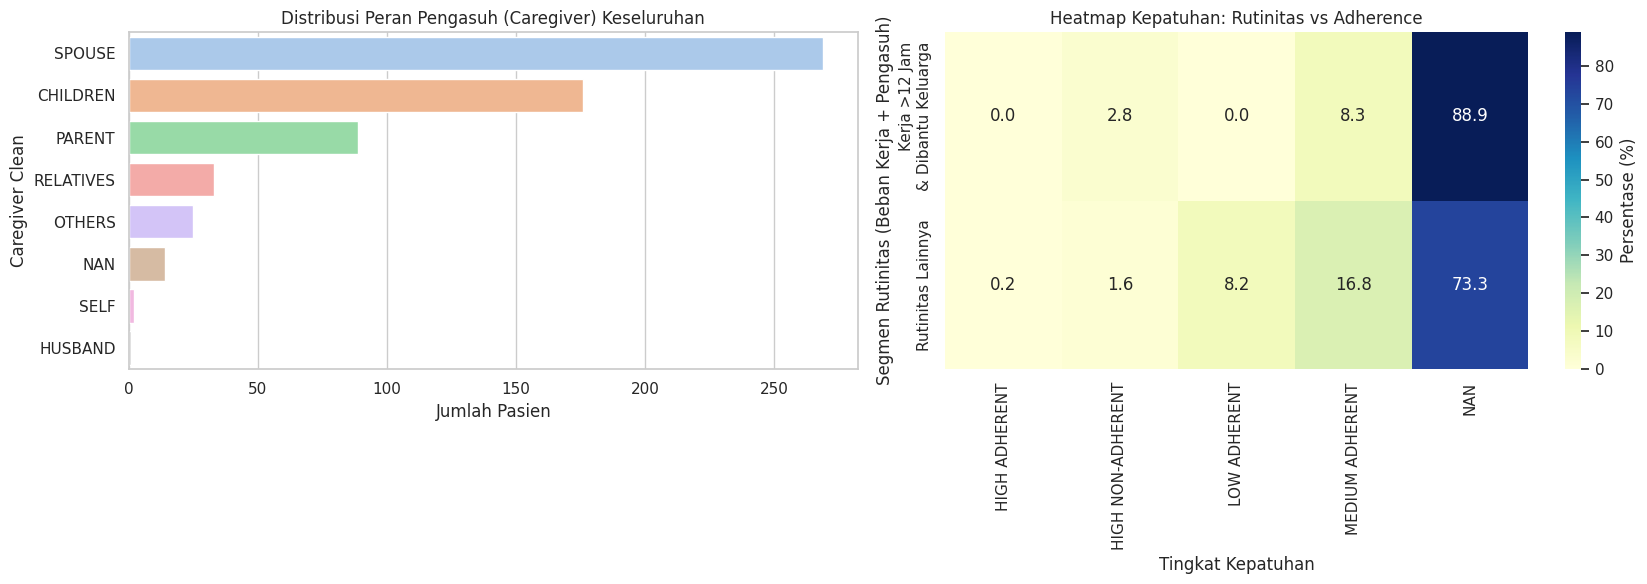

In [15]:
### Pertanyaan 3: Rutinitas Harian dan Peran Pengasuh (Caregiver)
#"Bagaimana perbandingan rasio 'High Adherent' antara pasien yang bekerja lebih dari 12 jam sehari dan mengurus dirinya sendiri ('Self') dengan mereka yang dibantu oleh keluarga ('Spouse/Children')?"*
def flag_routine(row):
    hours_str = str(row['How many hours do work in a day']).strip().upper()
    caregiver = str(row['Who is your care giver']).strip().upper()
    is_overwork = '24' in hours_str or '16' in hours_str or '20' in hours_str

    if is_overwork and caregiver == 'SELF':
        return 'Kerja >12 Jam\n& Mandiri'
    elif is_overwork and caregiver in ['SPOUSE', 'CHILDREN', 'HUSBAND']:
        return 'Kerja >12 Jam\n& Dibantu Keluarga'
    else:
        return 'Rutinitas Lainnya'

df['Routine_Segment'] = df.apply(flag_routine, axis=1)
routine_adherence = pd.crosstab(df['Routine_Segment'], df[col_target], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(17, 6))

# Visualisasi 1: Countplot Caregiver secara umum
df['Caregiver Clean'] = df['Who is your care giver'].astype(str).str.strip().str.upper()
sns.countplot(data=df, y='Caregiver Clean', order=df['Caregiver Clean'].value_counts().index, ax=ax[0], palette='pastel')
ax[0].set_title('Distribusi Peran Pengasuh (Caregiver) Keseluruhan', fontsize=12)
ax[0].set_xlabel('Jumlah Pasien')

# Visualisasi 2: Heatmap Kepatuhan
sns.heatmap(routine_adherence, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Persentase (%)'}, ax=ax[1])
ax[1].set_title('Heatmap Kepatuhan: Rutinitas vs Adherence', fontsize=12)
ax[1].set_ylabel('Segmen Rutinitas (Beban Kerja + Pengasuh)')
ax[1].set_xlabel('Tingkat Kepatuhan')

plt.tight_layout()
plt.show()

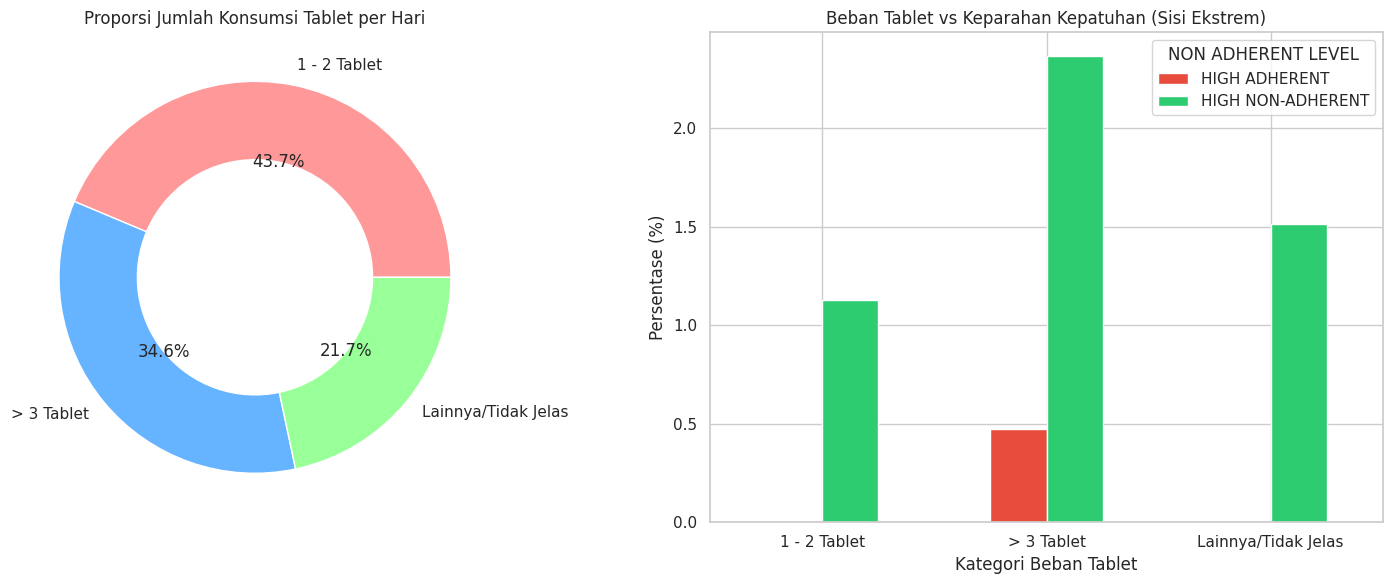

In [16]:
### Pertanyaan 4: Beban Resep dan Alasan Konsumsi Obat
#"Berapa tingkat peningkatan persentase 'High Non-Adherent' pada pasien yang meminum lebih dari 3 tablet sehari dibandingkan pasien dengan 1-2 tablet per hari?"*
def flag_tablets(row):
    tabs = str(row['How many tablets do you take in a day']).strip().upper()
    if 'ABOVE THREE' in tabs or tabs == '6':
        return '> 3 Tablet'
    elif tabs in ['ONE', 'TWO']:
        return '1 - 2 Tablet'
    else:
        return 'Lainnya/Tidak Jelas'

df['Tablet_Burden'] = df.apply(flag_tablets, axis=1)
tablet_adherence = pd.crosstab(df['Tablet_Burden'], df[col_target], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Visualisasi 1: Donut chart distribusi beban tablet
tab_counts = df['Tablet_Burden'].value_counts()
ax[0].pie(tab_counts, labels=tab_counts.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4), colors=['#ff9999','#66b3ff','#99ff99'])
ax[0].set_title('Proporsi Jumlah Konsumsi Tablet per Hari', fontsize=12)

# Visualisasi 2: Barplot Fokus Pada Kelas Ekstrem (Jika ada label HIGH)
cols_to_plot = [c for c in tablet_adherence.columns if 'HIGH' in c]
if len(cols_to_plot) > 0:
    tablet_adherence[cols_to_plot].plot(kind='bar', ax=ax[1], color=['#e74c3c', '#2ecc71'])
else:
    tablet_adherence.plot(kind='bar', ax=ax[1], colormap='Set1')

ax[1].set_title('Beban Tablet vs Keparahan Kepatuhan (Sisi Ekstrem)', fontsize=12)
ax[1].set_ylabel('Persentase (%)')
ax[1].set_xlabel('Kategori Beban Tablet')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3404/18322365.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_health.index, x=top_health.values, ax=ax[0], palette='magma')
/tmp/ipykernel_3404/18322365.py:17: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=disease_adherence.reset_index().melt(id_vars='Health Condition Clean'),


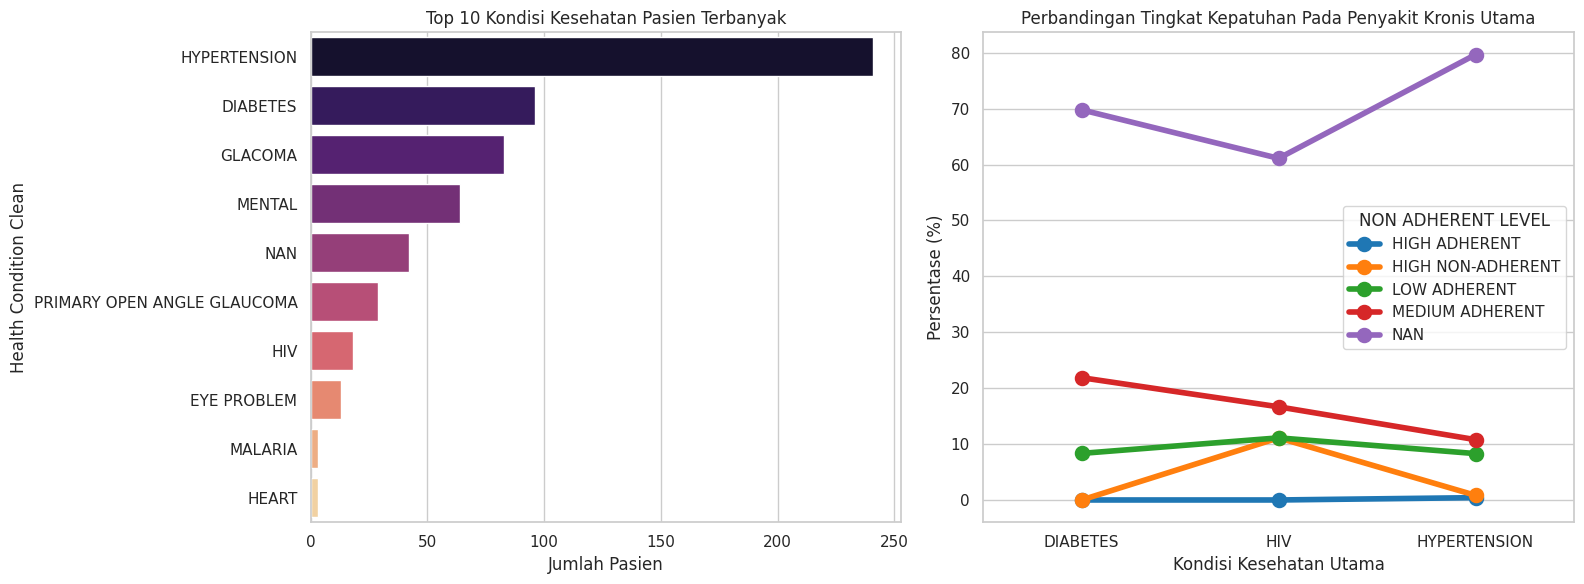

In [17]:
### Pertanyaan 5: Kondisi Kesehatan Spesifik
#"Di antara pasien HIV, Hipertensi, dan Diabetes, kelompok manakah yang mencatatkan rasio 'High Non-Adherent' tertinggi?"*
major_diseases = ['HIV', 'HYPERTENSION', 'DIABETES']
df['Health Condition Clean'] = df['Health Condition'].astype(str).str.strip().str.upper()
df_disease = df[df['Health Condition Clean'].isin(major_diseases)]
disease_adherence = pd.crosstab(df_disease['Health Condition Clean'], df_disease[col_target], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi 1: Barplot horizontal Top 10 Kondisi Kesehatan
top_health = df['Health Condition Clean'].value_counts().iloc[:10]
sns.barplot(y=top_health.index, x=top_health.values, ax=ax[0], palette='magma')
ax[0].set_title('Top 10 Kondisi Kesehatan Pasien Terbanyak', fontsize=12)
ax[0].set_xlabel('Jumlah Pasien')

# Visualisasi 2: Pointplot untuk melihat tren / perbandingan secara tajam
sns.pointplot(data=disease_adherence.reset_index().melt(id_vars='Health Condition Clean'),
              x='Health Condition Clean', y='value', hue=col_target, markers='o', scale=1.5, ax=ax[1], palette='tab10')
ax[1].set_title('Perbandingan Tingkat Kepatuhan Pada Penyakit Kronis Utama', fontsize=12)
ax[1].set_ylabel('Persentase (%)')
ax[1].set_xlabel('Kondisi Kesehatan Utama')

plt.tight_layout()
plt.show()

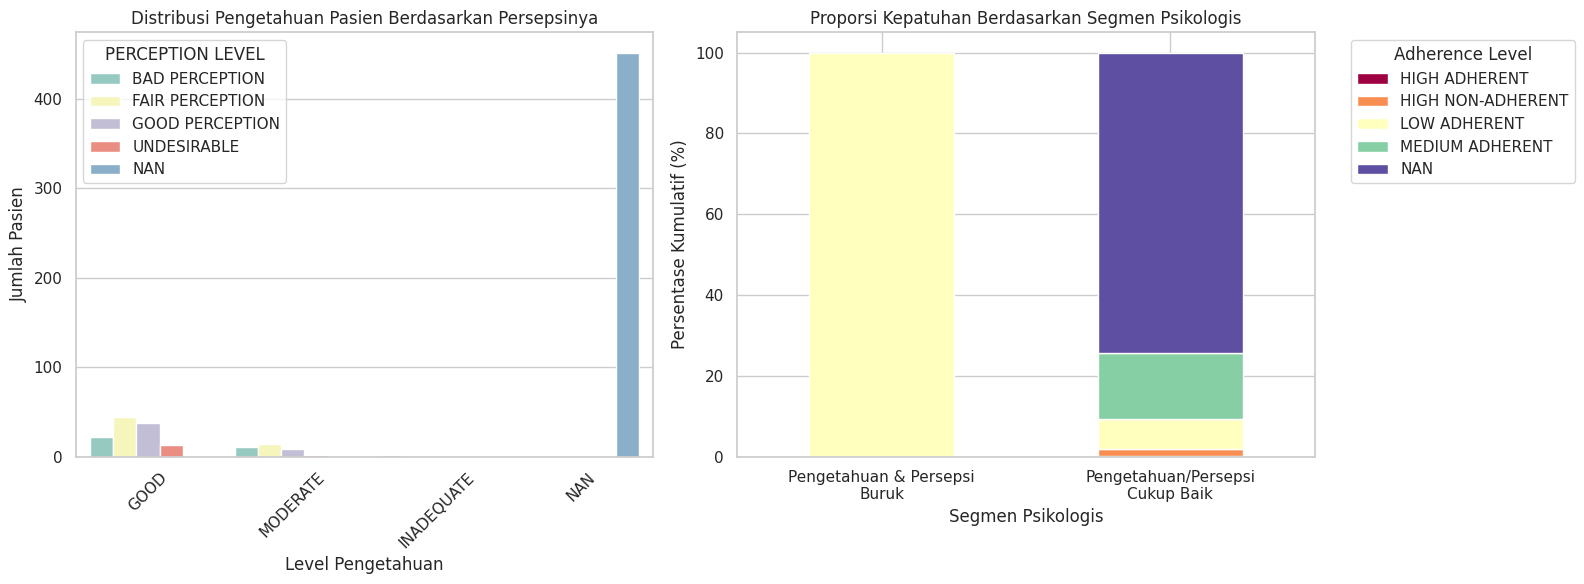

In [18]:
### Pertanyaan 6: Pengaruh Level Pengetahuan, Persepsi, dan Perilaku
#"Seberapa besar korelasi antara pasien dengan 'KNOWLEDGE LEVEL: Inadequate' dan 'PERCEPTION LEVEL: Bad' terhadap 'HIGH NON-ADHERENT'?"*
df['KNOWLEDGE LEVEL'] = df['KNOWLEDGE LEVEL'].astype(str).str.strip().str.upper()
df['PERCEPTION LEVEL'] = df['PERCEPTION LEVEL'].astype(str).str.strip().str.upper()

def flag_psychological(row):
    know = row['KNOWLEDGE LEVEL']
    percep = row['PERCEPTION LEVEL']
    if 'INADEQUATE' in know and 'BAD' in percep:
        return 'Pengetahuan & Persepsi\nBuruk'
    else:
        return 'Pengetahuan/Persepsi\nCukup Baik'

df['Psycho_Segment'] = df.apply(flag_psychological, axis=1)
psycho_adherence = pd.crosstab(df['Psycho_Segment'], df[col_target], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi 1: Countplot (Clustered) distribusi gabungan Pengetahuan & Persepsi
sns.countplot(data=df, x='KNOWLEDGE LEVEL', hue='PERCEPTION LEVEL', ax=ax[0], palette='Set3')
ax[0].set_title('Distribusi Pengetahuan Pasien Berdasarkan Persepsinya', fontsize=12)
ax[0].set_xlabel('Level Pengetahuan')
ax[0].set_ylabel('Jumlah Pasien')
ax[0].tick_params(axis='x', rotation=45)

# Visualisasi 2: Stacked Barplot untuk melihat kombinasi tersebut dengan Adherence
psycho_adherence.plot(kind='bar', stacked=True, ax=ax[1], colormap='Spectral')
ax[1].set_title('Proporsi Kepatuhan Berdasarkan Segmen Psikologis', fontsize=12)
ax[1].set_ylabel('Persentase Kumulatif (%)')
ax[1].set_xlabel('Segmen Psikologis')
ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(title='Adherence Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
